# Model Comparison Analysis: FEVS 2024 — Predicting Federal Employee Job Satisfaction

**Dataset:** 2024 Federal Employee Viewpoint Survey (FEVS) Public Release Data  
**Target Variable:** Q69 — Job Satisfaction (1–5 Likert Scale)  
**Predictors:** Telework frequency, Work-Life Balance, Employee Engagement Index, Demographics  
**Task Type:** Regression (continuous Likert outcome)

This notebook systematically tests **10+ models**, compares their performance, and identifies the **top 4–5 best models** for our research question.

In [1]:
# ============================================================
# Section 1: Import Required Libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import joblib
import os

# Scikit-learn
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             make_scorer)

# Regression Models
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet,
                                  SGDRegressor)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                              AdaBoostRegressor, ExtraTreesRegressor,
                              BaggingRegressor)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
import xgboost as xgb
import lightgbm as lgb

# Hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

from scipy import stats

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("All libraries imported successfully.")

All libraries imported successfully.


## Section 2: Load and Explore the Dataset
Load the 2024 FEVS Public Release Data File (PRDF) and examine its structure.

In [2]:
# ============================================================
# Section 2: Load and Explore the Dataset
# ============================================================
df = pd.read_csv('C:/Users/karan/Downloads/FEVS/FEVS_2024_PRDF.csv', low_memory=False)

print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nData Types:\n{df.dtypes.value_counts()}")
print(f"\nTotal Missing Values: {df.isnull().sum().sum():,}")
print(f"Rows with Missing Data: {df.isnull().any(axis=1).sum():,}")

# Key variables
print("\n" + "="*50)
print("KEY VARIABLES FOR OUR MODEL")
print("="*50)

print("\n📊 Q69 — Job Satisfaction (Dependent Variable, 1-5):")
q69_dist = pd.to_numeric(df['Q69'], errors='coerce').value_counts().sort_index()
print(q69_dist)
print(f"   Mean: {pd.to_numeric(df['Q69'], errors='coerce').mean():.2f}")

print("\n📊 Q61 — Telework Frequency (Independent Variable, 1-5):")
print(df['Q61'].value_counts().sort_index())

print("\n📊 Q64 — Work-Life Balance Satisfaction (1-5):")
print(df['Q64'].value_counts().sort_index())

print("\n📊 Demographics:")
print(f"   Age Groups:  {df['DAGEGRP'].value_counts().to_dict()}")
print(f"   Gender:      {df['DSEX'].value_counts().to_dict()}")
print(f"   Supervisory: {df['DSUPER'].value_counts().to_dict()}")
print(f"   Fed Tenure:  {df['DFEDTEN'].value_counts().to_dict()}")

Dataset Shape: 674,207 rows × 96 columns

Data Types:
object     51
float64    44
int64       1
dtype: int64

Total Missing Values: 1,881,545
Rows with Missing Data: 312,355

KEY VARIABLES FOR OUR MODEL

📊 Q69 — Job Satisfaction (Dependent Variable, 1-5):
1.0     47350
2.0     79827
3.0    135145
4.0    236220
5.0    149365
Name: Q69, dtype: int64
   Mean: 3.56

📊 Q61 — Telework Frequency (Independent Variable, 1-5):
1     40062
2     39944
3    112405
4    206010
5    223382
X     31266
Name: Q61, dtype: int64

📊 Q64 — Work-Life Balance Satisfaction (1-5):
1     43756
2     59413
3    140093
4    230093
5    159368
X     19084
Name: Q64, dtype: int64

📊 Demographics:
   Age Groups:  {'B': 441972, 'A': 151314}
   Gender:      {'A': 269549, 'B': 256446}
   Supervisory: {'A': 494780, 'B': 133618}
   Fed Tenure:  {'A': 276499, 'B': 199531, 'C': 152612}


## Section 3: Data Preprocessing and Feature Engineering
- Convert survey items to numeric (handle "X" = Not Applicable)
- Encode demographic categories
- Create Employee Engagement Index (EEI) composite
- Drop missing values (listwise deletion)

Original dataset:  674,207 rows
After cleaning:    453,082 rows
Dropped:           221,125 rows (32.8%)

Feature matrix:    (453082, 7)
Features:          ['Q61', 'Q64', 'EEI', 'DAGEGRP', 'DSEX', 'DSUPER', 'DFEDTEN']

Target (Q69) stats:
  Mean:   3.626
  Std:    1.167
  Min:    1
  Max:    5


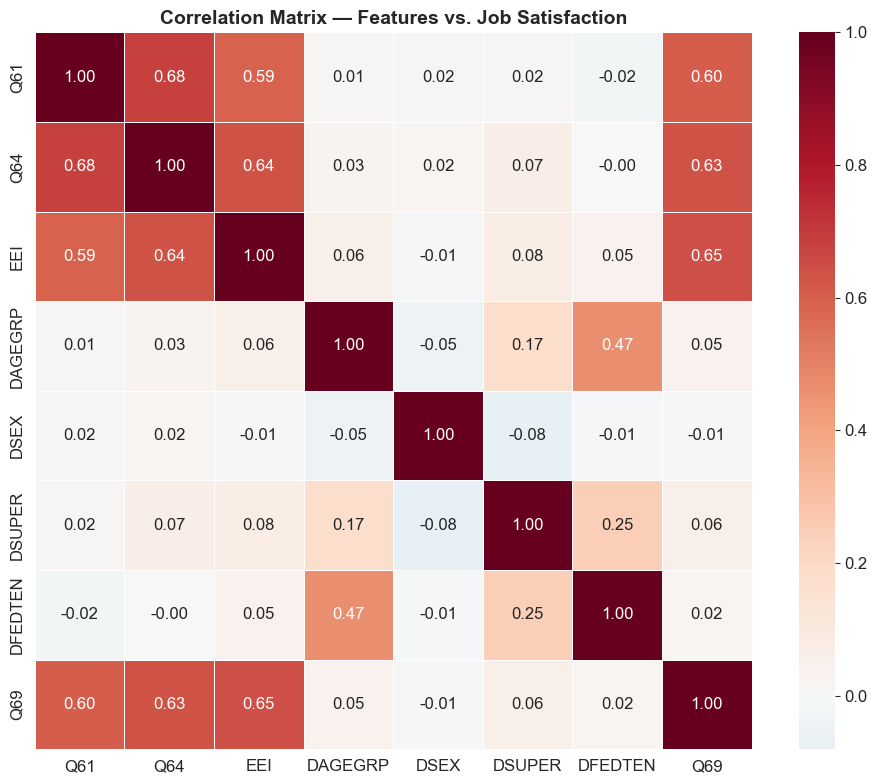


Correlation with Job Satisfaction (Q69):
Q69        1.000000
EEI        0.646927
Q64        0.633736
Q61        0.603048
DSUPER     0.058324
DAGEGRP    0.047304
DFEDTEN    0.016325
DSEX      -0.011163


In [3]:
# ============================================================
# Section 3: Data Preprocessing and Feature Engineering
# ============================================================

# Define variables
eei_items = ['Q3', 'Q4', 'Q6', 'Q11', 'Q12', 'Q13', 'Q14']  # OPM Engagement Index items
feature_cols = ['Q61', 'Q64'] + eei_items + ['DAGEGRP', 'DSEX', 'DSUPER', 'DFEDTEN']
target_col = 'Q69'

# Select needed columns
df_model = df[feature_cols + [target_col]].copy()

# Convert survey items to numeric ("X" = Not Applicable → NaN)
for col in ['Q61', 'Q64', 'Q69'] + eei_items:
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

# Encode demographics as numeric
demo_mapping = {
    'DAGEGRP': {'A': 0, 'B': 1},       # A = Under 40, B = 40 and over
    'DSEX': {'A': 0, 'B': 1},          # A = Male, B = Female
    'DSUPER': {'A': 0, 'B': 1},        # A = Non-supervisor, B = Supervisor
    'DFEDTEN': {'A': 0, 'B': 1, 'C': 2}  # A = <10yr, B = 10–20yr, C = 20+yr
}
for col, mapping in demo_mapping.items():
    df_model[col] = df_model[col].map(mapping)

# Drop rows with any missing values (listwise deletion)
df_clean = df_model.dropna().copy()

# Create EEI composite (mean of 7 engagement items)
df_clean['EEI'] = df_clean[eei_items].mean(axis=1)

# Final feature set
final_features = ['Q61', 'Q64', 'EEI', 'DAGEGRP', 'DSEX', 'DSUPER', 'DFEDTEN']
X = df_clean[final_features].values
y = df_clean[target_col].values

print(f"Original dataset:  {df.shape[0]:,} rows")
print(f"After cleaning:    {df_clean.shape[0]:,} rows")
print(f"Dropped:           {df.shape[0] - df_clean.shape[0]:,} rows ({(df.shape[0] - df_clean.shape[0])/df.shape[0]*100:.1f}%)")
print(f"\nFeature matrix:    {X.shape}")
print(f"Features:          {final_features}")
print(f"\nTarget (Q69) stats:")
print(f"  Mean:   {y.mean():.3f}")
print(f"  Std:    {y.std():.3f}")
print(f"  Min:    {y.min():.0f}")
print(f"  Max:    {y.max():.0f}")

# Show correlation matrix
corr_df = df_clean[final_features + [target_col]].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Features vs. Job Satisfaction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nCorrelation with Job Satisfaction (Q69):")
print(corr_df[target_col].sort_values(ascending=False).to_string())

## Section 4: Train-Test Split and Scaling
Split data 80/20, standardize features for fair comparison across models.

In [4]:
# ============================================================
# Section 4: Train-Test Split and Scaling
# ============================================================
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Sample for expensive models (KNN, MLP)
SAMPLE_SIZE = 30000
np.random.seed(42)
sample_idx = np.random.choice(len(X_train_scaled), SAMPLE_SIZE, replace=False)
X_train_sample = X_train_scaled[sample_idx]
y_train_sample = y_train[sample_idx]

# CV strategy
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set:     {X_test.shape[0]:,} samples")
print(f"Sample set:   {SAMPLE_SIZE:,} samples (for expensive models)")
print(f"CV Strategy:  5-Fold Cross-Validation")

Training set: 362,465 samples
Test set:     90,617 samples
Sample set:   30,000 samples (for expensive models)
CV Strategy:  5-Fold Cross-Validation


In [5]:
# ============================================================
# Section 5: Define, Train, and Evaluate All Models
# ============================================================
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                              AdaBoostRegressor, ExtraTreesRegressor, BaggingRegressor)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb

# Fast models (full training data)
fast_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.01),
    'Elastic Net': ElasticNet(alpha=0.01, l1_ratio=0.5),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42),
    'AdaBoost': AdaBoostRegressor(n_estimators=100, random_state=42),
    'Extra Trees': ExtraTreesRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'Bagging': BaggingRegressor(n_estimators=50, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1, verbosity=0),
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1),
}

# Slow models (sampled training data)
slow_models = {
    'KNN': KNeighborsRegressor(n_neighbors=7, n_jobs=-1),
    'MLP Neural Net': MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=200, random_state=42, early_stopping=True),
}

results = []
cv_scores_dict = {}
trained_models = {}

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Train model, compute metrics, run cross-validation."""
    start = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - start

    y_pred = model.predict(X_te)
    y_pred_train = model.predict(X_tr)

    r2 = r2_score(y_te, y_pred)
    r2_train = r2_score(y_tr, y_pred_train)
    mae = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))

    # CV on sample for speed
    cv_idx = np.random.choice(len(X_tr), min(50000, len(X_tr)), replace=False)
    cv_r2 = cross_val_score(model, X_tr[cv_idx], y_tr[cv_idx], cv=kf, scoring='r2', n_jobs=-1)
    cv_scores_dict[name] = cv_r2

    return {
        'Model': name,
        'R² (Test)': round(r2, 4),
        'R² (Train)': round(r2_train, 4),
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        'CV R² Mean': round(cv_r2.mean(), 4),
        'CV R² Std': round(cv_r2.std(), 4),
        'Train Time (s)': round(train_time, 2),
    }, model

print("Training 14 models... (this may take a few minutes)\n")

for name, model in fast_models.items():
    print(f"  ▸ {name}...", end=" ", flush=True)
    result, fitted = evaluate_model(name, model, X_train_scaled, y_train, X_test_scaled, y_test)
    results.append(result)
    trained_models[name] = fitted
    print(f"R²={result['R² (Test)']:.4f}  MAE={result['MAE']:.4f}  ({result['Train Time (s)']:.1f}s)")

for name, model in slow_models.items():
    print(f"  ▸ {name} (sampled)...", end=" ", flush=True)
    result, fitted = evaluate_model(name, model, X_train_sample, y_train_sample, X_test_scaled, y_test)
    results.append(result)
    trained_models[name] = fitted
    print(f"R²={result['R² (Test)']:.4f}  MAE={result['MAE']:.4f}  ({result['Train Time (s)']:.1f}s)")

print("\n✓ All 14 models trained and evaluated!")

Training 14 models... (this may take a few minutes)

  ▸ Linear Regression... R²=0.5254  MAE=0.6172  (0.1s)
  ▸ Ridge Regression... R²=0.5254  MAE=0.6172  (0.1s)
  ▸ Lasso Regression... R²=0.5250  MAE=0.6192  (0.1s)
  ▸ Elastic Net... R²=0.5253  MAE=0.6184  (0.0s)
  ▸ Decision Tree... R²=0.5287  MAE=0.6072  (0.2s)
  ▸ Random Forest... R²=0.5307  MAE=0.6063  (3.1s)
  ▸ Gradient Boosting... R²=0.5321  MAE=0.6057  (18.1s)
  ▸ AdaBoost... R²=0.4703  MAE=0.6945  (2.5s)
  ▸ Extra Trees... R²=0.5308  MAE=0.6074  (2.3s)
  ▸ Bagging... R²=0.5138  MAE=0.6136  (2.4s)
  ▸ XGBoost... R²=0.5322  MAE=0.6056  (2.7s)
  ▸ LightGBM... R²=0.5322  MAE=0.6057  (0.4s)
  ▸ KNN (sampled)... R²=0.4689  MAE=0.6425  (0.0s)
  ▸ MLP Neural Net (sampled)... R²=0.5259  MAE=0.6202  (2.4s)

✓ All 14 models trained and evaluated!
